In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../Datos_Cundinamarca.csv")

In [3]:
print(df.shape)

df.head()

df.info()

(470818, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470818 entries, 0 to 470817
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   PERIODO                   470818 non-null  int64  
 1   COLE_AREA_UBICACION       470620 non-null  object 
 2   COLE_BILINGUE             393463 non-null  object 
 3   COLE_GENERO               470818 non-null  object 
 4   COLE_JORNADA              470818 non-null  object 
 5   COLE_MCPIO_UBICACION      470818 non-null  object 
 6   ESTU_FECHANACIMIENTO      470818 non-null  object 
 7   ESTU_GENERO               470553 non-null  object 
 8   ESTU_PAIS_RESIDE          470818 non-null  object 
 9   FAMI_CUARTOSHOGAR         464260 non-null  object 
 10  FAMI_EDUCACIONMADRE       460119 non-null  object 
 11  FAMI_EDUCACIONPADRE       460065 non-null  object 
 12  FAMI_ESTRATOVIVIENDA      459209 non-null  object 
 13  FAMI_PERSONASHOGAR        46419

In [ ]:

#Nulos
df.isnull().sum().sort_values(ascending=False)

PUNT_SOCIALES_CIUDADANAS    171841
PUNT_GLOBAL                 171841
PUNT_LECTURA_CRITICA        171841
PUNT_C_NATURALES            171841
COLE_BILINGUE                77355
FAMI_ESTRATOVIVIENDA         11609
FAMI_EDUCACIONPADRE          10753
FAMI_EDUCACIONMADRE          10699
FAMI_TIENEINTERNET            9766
FAMI_TIENECOMPUTADOR          7473
FAMI_TIENEAUTOMOVIL           6736
FAMI_PERSONASHOGAR            6620
FAMI_CUARTOSHOGAR             6558
FAMI_TIENELAVADORA            6420
ESTU_GENERO                    265
COLE_AREA_UBICACION            198
DESEMP_INGLES                   71
PUNT_INGLES                     28
ESTU_FECHANACIMIENTO             0
ESTU_PAIS_RESIDE                 0
COLE_JORNADA                     0
COLE_GENERO                      0
PERIODO                          0
COLE_MCPIO_UBICACION             0
PUNT_MATEMATICAS                 0
dtype: int64

In [10]:
df["PUNT_GLOBAL"].isnull().sum()

np.int64(171841)

In [11]:
df = df.dropna(subset=["PUNT_GLOBAL"])

In [13]:
df.shape

(298977, 25)

In [12]:
df.duplicated().sum()

np.int64(72842)

In [14]:
df = df.drop_duplicates()

df.shape

(226135, 25)

In [15]:
cols = [
'COLE_AREA_UBICACION',
'COLE_BILINGUE',
'COLE_GENERO',
'COLE_JORNADA',
'COLE_MCPIO_UBICACION',
'ESTU_FECHANACIMIENTO',
'ESTU_GENERO',
'ESTU_PAIS_RESIDE',
'FAMI_CUARTOSHOGAR',
'FAMI_EDUCACIONMADRE',
'FAMI_EDUCACIONPADRE',
'FAMI_ESTRATOVIVIENDA',
'FAMI_PERSONASHOGAR',
'FAMI_TIENEAUTOMOVIL',
'FAMI_TIENECOMPUTADOR',
'FAMI_TIENEINTERNET',
'FAMI_TIENELAVADORA'
]

df[cols].isnull().sum().sort_values(ascending=False)

COLE_BILINGUE           41221
FAMI_ESTRATOVIVIENDA     5275
FAMI_TIENEINTERNET       4906
FAMI_EDUCACIONPADRE      4823
FAMI_EDUCACIONMADRE      4796
FAMI_PERSONASHOGAR       3019
FAMI_TIENEAUTOMOVIL      2985
FAMI_CUARTOSHOGAR        2888
FAMI_TIENECOMPUTADOR     2814
FAMI_TIENELAVADORA       2771
ESTU_GENERO               253
COLE_AREA_UBICACION         0
ESTU_PAIS_RESIDE            0
COLE_GENERO                 0
ESTU_FECHANACIMIENTO        0
COLE_JORNADA                0
COLE_MCPIO_UBICACION        0
dtype: int64

Cada vez que el colegio no sea reportado como Biligue se asumirá que no lo es.

In [21]:
df["COLE_BILINGUE"] = (
    df["COLE_BILINGUE"]
    .fillna("N")
)

In [22]:
df["COLE_BILINGUE"] = (
    df["COLE_BILINGUE"]
    .fillna("N")
)

cols_no_info = [
'FAMI_TIENEINTERNET',
'FAMI_EDUCACIONPADRE',
'FAMI_EDUCACIONMADRE',
'FAMI_ESTRATOVIVIENDA',
'FAMI_PERSONASHOGAR',
'FAMI_CUARTOSHOGAR',
'FAMI_TIENEAUTOMOVIL',
'FAMI_TIENECOMPUTADOR',
'FAMI_TIENELAVADORA'
]

for col in cols_no_info:
    df[col] = df[col].fillna(
        "No informa"
    )

In [24]:
df.isnull().sum().sort_values(
ascending=False
).head(10)

PUNT_INGLES             17
DESEMP_INGLES           16
COLE_BILINGUE            0
COLE_AREA_UBICACION      0
COLE_JORNADA             0
COLE_MCPIO_UBICACION     0
ESTU_FECHANACIMIENTO     0
COLE_GENERO              0
PERIODO                  0
ESTU_PAIS_RESIDE         0
dtype: int64

Acá creamos copia del Dataframe para comenzar a desarrollar algo especifico para el modelo

In [26]:
df_vulnerabilidad = df.copy()

df_vulnerabilidad.shape

(226135, 25)

In [27]:
cols_drop = [
'DESEMP_INGLES',
'PUNT_INGLES',
'PUNT_MATEMATICAS',
'PUNT_SOCIALES_CIUDADANAS',
'PUNT_C_NATURALES',
'PUNT_LECTURA_CRITICA'
]

df_vulnerabilidad = (
    df_vulnerabilidad
    .drop(columns=cols_drop)
)

In [28]:
df_vulnerabilidad.columns

Index(['PERIODO', 'COLE_AREA_UBICACION', 'COLE_BILINGUE', 'COLE_GENERO',
       'COLE_JORNADA', 'COLE_MCPIO_UBICACION', 'ESTU_FECHANACIMIENTO',
       'ESTU_GENERO', 'ESTU_PAIS_RESIDE', 'FAMI_CUARTOSHOGAR',
       'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE', 'FAMI_ESTRATOVIVIENDA',
       'FAMI_PERSONASHOGAR', 'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENECOMPUTADOR',
       'FAMI_TIENEINTERNET', 'FAMI_TIENELAVADORA', 'PUNT_GLOBAL'],
      dtype='object')

Tranformar fecha en variable útil

In [29]:
df_vulnerabilidad[
"ESTU_FECHANACIMIENTO"
] = pd.to_datetime(
df_vulnerabilidad[
"ESTU_FECHANACIMIENTO"
],
errors='coerce',
dayfirst=True
)

In [31]:
df_vulnerabilidad[
"EDAD"
] = (
2019
-
df_vulnerabilidad[
"ESTU_FECHANACIMIENTO"
].dt.year
)

In [32]:
df_vulnerabilidad[
"EDAD"
].describe()

count    226005.000000
mean         19.731099
std           4.974855
min          -3.000000
25%          17.000000
50%          20.000000
75%          21.000000
max         122.000000
Name: EDAD, dtype: float64

In [33]:
df_vulnerabilidad[
"ANIO_EXAMEN"
] = (
df_vulnerabilidad[
"PERIODO"
]
.astype(str)
.str[:4]
.astype(int)
)

In [34]:
df_vulnerabilidad[
["PERIODO",
"ANIO_EXAMEN"]
].head()

,PERIODO,ANIO_EXAMEN
0,20224,2022
1,20224,2022
2,20224,2022
3,20224,2022
4,20224,2022


In [ ]:
# Se transforma la fecha de nacimiento en una variable de edad estimada al momento
# de presentar la prueba Saber 11. Debido a que el examen también puede ser presentado
# por personas que culminaron el bachillerato de manera tardía o mediante procesos de
# validación, no se restringe únicamente a edades típicas de grado 11. Sin embargo,
# se eliminan registros con edades claramente inconsistentes para evitar errores de
# digitación o datos atípicos extremos.


df_vulnerabilidad["EDAD"] = (
    df_vulnerabilidad["ANIO_EXAMEN"] 
    - df_vulnerabilidad["ESTU_FECHANACIMIENTO"].dt.year
)

In [36]:
df_vulnerabilidad["EDAD"].describe()

count    226005.000000
mean         17.932528
std           4.135550
min          -2.000000
25%          17.000000
50%          17.000000
75%          18.000000
max         119.000000
Name: EDAD, dtype: float64

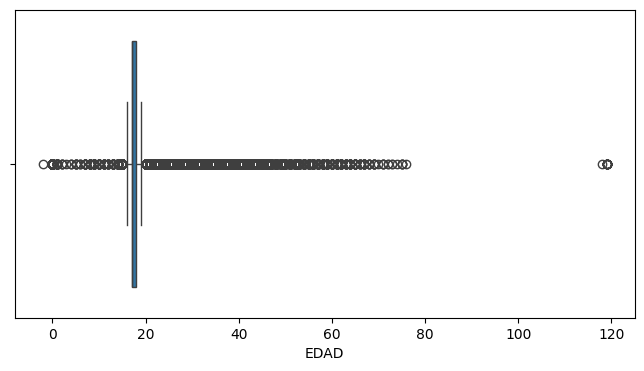

In [37]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_vulnerabilidad["EDAD"])
plt.show()

In [38]:
# Aunque la prueba Saber 11 puede ser presentada por personas que culminaron el
# bachillerato de manera tardía o mediante procesos de validación, se filtran
# edades extremas para mantener una población coherente con el objetivo del
# estudio. Se conserva un rango amplio (14–35 años) que incluye tanto la
# población típica de grado 11 como casos de rezago académico o validación,
# eliminando únicamente edades poco representativas para la pregunta de
# investigación o potencialmente asociadas a errores de registro.

df_vulnerabilidad = df_vulnerabilidad[
    df_vulnerabilidad["EDAD"] >= 14
]

df_vulnerabilidad = df_vulnerabilidad[
    df_vulnerabilidad["EDAD"] <= 35
]

In [39]:
df_vulnerabilidad = df_vulnerabilidad.drop(
    columns=["ESTU_FECHANACIMIENTO", "ANIO_EXAMEN"]
)

DEFINICIÓN PREGUNTA:

In [40]:
cols_contexto = [
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENECOMPUTADOR",
    "FAMI_EDUCACIONPADRE",
    "FAMI_EDUCACIONMADRE",
    "FAMI_TIENEAUTOMOVIL"
]

for col in cols_contexto:
    print("\n")
    print(col)
    print(df_vulnerabilidad[col].value_counts())



FAMI_ESTRATOVIVIENDA
FAMI_ESTRATOVIVIENDA
Estrato 2      104625
Estrato 3       52253
Estrato 1       48401
Estrato 4       10541
Estrato 5        3154
Estrato 6        1864
Sin Estrato      1467
Name: count, dtype: int64


FAMI_TIENEINTERNET
FAMI_TIENEINTERNET
Si    142119
No     80186
Name: count, dtype: int64


FAMI_TIENECOMPUTADOR
FAMI_TIENECOMPUTADOR
Si    153756
No     68549
Name: count, dtype: int64


FAMI_EDUCACIONPADRE
FAMI_EDUCACIONPADRE
Secundaria (Bachillerato) completa      54020
Primaria incompleta                     38847
Primaria completa                       33893
Secundaria (Bachillerato) incompleta    30808
Educación profesional completa          19439
Técnica o tecnológica completa          12495
No sabe                                 11053
Ninguno                                  6479
Postgrado                                5448
Técnica o tecnológica incompleta         4304
Educación profesional incompleta         4084
No Aplica                               

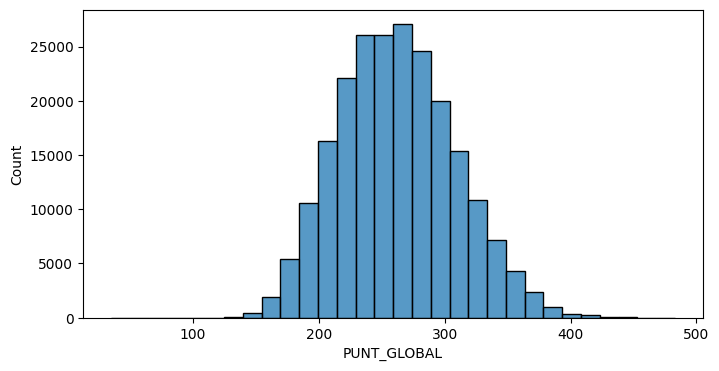

count    222305.000000
mean        262.164085
std          46.254551
min          35.000000
25%         229.000000
50%         260.000000
75%         293.000000
max         483.000000
Name: PUNT_GLOBAL, dtype: float64

In [41]:
plt.figure(figsize=(8,4))
sns.histplot(df_vulnerabilidad["PUNT_GLOBAL"], bins=30)
plt.show()

df_vulnerabilidad["PUNT_GLOBAL"].describe()

In [42]:
df_vulnerabilidad["FAMI_EDUCACIONPADRE"].value_counts()

df_vulnerabilidad["FAMI_EDUCACIONMADRE"].value_counts()

FAMI_EDUCACIONMADRE
Secundaria (Bachillerato) completa      63388
Secundaria (Bachillerato) incompleta    33792
Primaria completa                       31743
Primaria incompleta                     28994
Educación profesional completa          23280
Técnica o tecnológica completa          18172
Postgrado                                6120
Técnica o tecnológica incompleta         5813
Educación profesional incompleta         4977
No sabe                                  3380
Ninguno                                  2434
No Aplica                                 212
Name: count, dtype: int64

In [74]:
# Se construye una variable de contexto favorable con base en criterios
# socioeconómicos y de acceso a recursos del hogar. Dado que el estrato es uno
# de los principales determinantes del nivel socioeconómico, los estudiantes
# pertenecientes a estratos 5 y 6 se clasifican automáticamente como contexto
# favorable. Para los demás estudiantes, se construye un puntaje acumulado a
# partir del acceso a internet, computador, automóvil y nivel educativo de los
# padres, buscando identificar hogares con mayores oportunidades y recursos.

df_vulnerabilidad["SCORE_CONTEXTO"] = 0

In [75]:
df_vulnerabilidad.loc[
    df_vulnerabilidad["FAMI_ESTRATOVIVIENDA"].isin(
        ["Estrato 5", "Estrato 6"]
    ),
    "SCORE_CONTEXTO"
] = 5

In [76]:
df_vulnerabilidad.loc[
    df_vulnerabilidad["FAMI_ESTRATOVIVIENDA"].isin(
        ["Estrato 3", "Estrato 4"]
    ),
    "SCORE_CONTEXTO"
] += 1

In [77]:
df_vulnerabilidad.loc[
    df_vulnerabilidad["FAMI_TIENEINTERNET"] == "Si",
    "SCORE_CONTEXTO"
] += 1

df_vulnerabilidad.loc[
    df_vulnerabilidad["FAMI_TIENECOMPUTADOR"] == "Si",
    "SCORE_CONTEXTO"
] += 1

df_vulnerabilidad.loc[
    df_vulnerabilidad["FAMI_TIENEAUTOMOVIL"] == "Si",
    "SCORE_CONTEXTO"
] += 1

In [78]:
educacion_alta = [
    "Educación profesional completa",
    "Postgrado",
    "Técnica o tecnológica completa"
]

df_vulnerabilidad.loc[
    df_vulnerabilidad["FAMI_EDUCACIONPADRE"].isin(
        educacion_alta
    ),
    "SCORE_CONTEXTO"
] += 1

df_vulnerabilidad.loc[
    df_vulnerabilidad["FAMI_EDUCACIONMADRE"].isin(
        educacion_alta
    ),
    "SCORE_CONTEXTO"
] += 1

In [79]:
df_vulnerabilidad["CONTEXTO_FAVORABLE"] = (
    df_vulnerabilidad["SCORE_CONTEXTO"] >= 4
).astype(int)

In [80]:
df_vulnerabilidad["CONTEXTO_FAVORABLE"].value_counts()

CONTEXTO_FAVORABLE
0    168384
1     53921
Name: count, dtype: int64

25% de los ESTUDIANTES SON CLASIFICADOS COMO CONTEXTO FAVORABLE

Se construye una variable objetivo denominada “riesgo oculto” con el fin de identificar estudiantes que, pese a pertenecer a contextos socioeconómicos favorables, presentan un desempeño académico bajo. Para ello, se utiliza el percentil 30 del puntaje global como umbral de referencia, clasificando como casos de riesgo a aquellos estudiantes con puntajes inferiores a dicho valor.

Dado que el grupo clasificado como contexto favorable representa aproximadamente el 25% de la población total, resulta esperable que estos estudiantes presenten, en promedio, mejores resultados académicos que el resto de la muestra. Por esta razón, utilizar el percentil 25 como umbral de bajo desempeño puede resultar demasiado restrictivo y generar un número reducido de casos. En consecuencia, se adopta el percentil 30 con el fin de capturar estudiantes que, aun perteneciendo a contextos favorables, presentan desempeños relativamente bajos frente a las expectativas asociadas a dicho grupo.

In [93]:
p25 = df_vulnerabilidad["PUNT_GLOBAL"].quantile(0.30)

print(p25)

235.0


In [94]:
df_vulnerabilidad["RIESGO_OCULTO"] = (
    (df_vulnerabilidad["CONTEXTO_FAVORABLE"] == 1)
    &
    (df_vulnerabilidad["PUNT_GLOBAL"] < p25)
).astype(int)

In [91]:
df_vulnerabilidad["RIESGO_OCULTO"].value_counts()

df_vulnerabilidad["RIESGO_OCULTO"].mean()

np.float64(0.037979352691122556)

In [95]:
df_vulnerabilidad["RIESGO_OCULTO"].value_counts()

RIESGO_OCULTO
0    215451
1      6854
Name: count, dtype: int64

6854 / 222305 ≈ 3.1%

In [96]:
df_vulnerabilidad.to_csv(
    "../Datos/df_modelo_vulnerabilidad.csv",
    index=False
)

In [98]:
p30 = df_vulnerabilidad[
    "PUNT_GLOBAL"
].quantile(0.30)

print(p30)

235.0


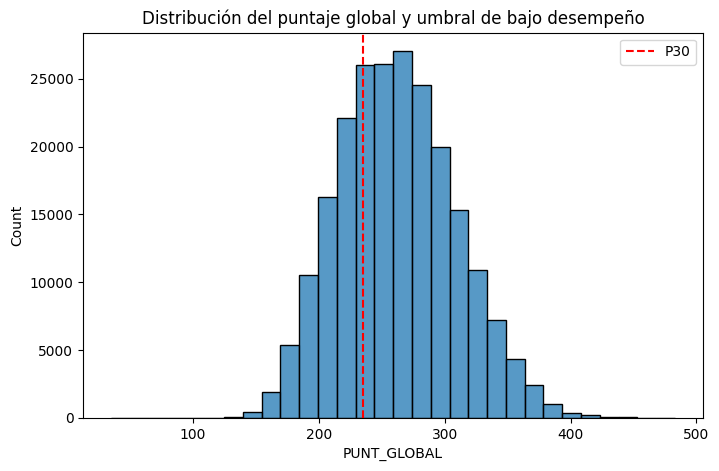

In [99]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_vulnerabilidad[
        "PUNT_GLOBAL"
    ],
    bins=30
)

plt.axvline(
    p30,
    color="red",
    linestyle="--",
    label="P30"
)

plt.legend()

plt.title(
    "Distribución del puntaje global y umbral de bajo desempeño"
)

plt.show()

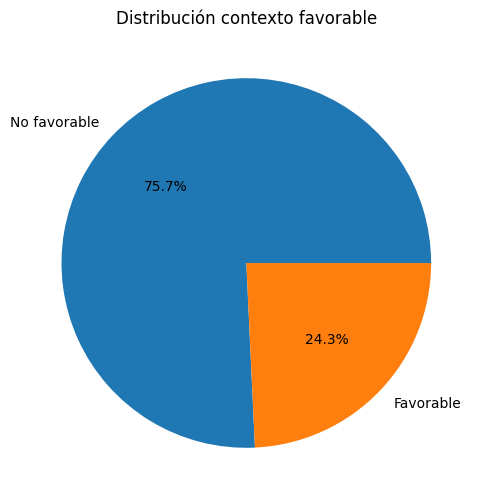

In [100]:
conteo = (
df_vulnerabilidad[
"CONTEXTO_FAVORABLE"
]
.value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
conteo,

labels=[
"No favorable",
"Favorable"
],

autopct='%1.1f%%'
)

plt.title(
"Distribución contexto favorable"
)

plt.show()

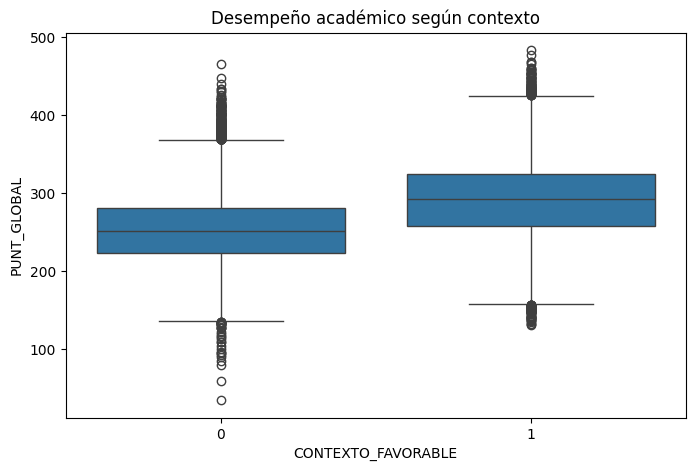

In [101]:
plt.figure(figsize=(8,5))

sns.boxplot(

x=
"CONTEXTO_FAVORABLE",

y=
"PUNT_GLOBAL",

data=
df_vulnerabilidad

)

plt.title(
"Desempeño académico según contexto"
)

plt.show()

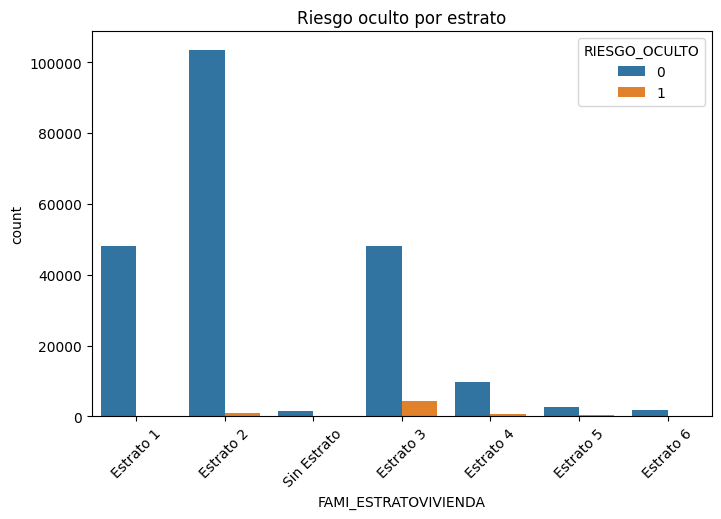

In [102]:
plt.figure(figsize=(8,5))

sns.countplot(

data=
df_vulnerabilidad,

x=
"FAMI_ESTRATOVIVIENDA",

hue=
"RIESGO_OCULTO"

)

plt.xticks(
rotation=45
)

plt.title(
"Riesgo oculto por estrato"
)

plt.show()

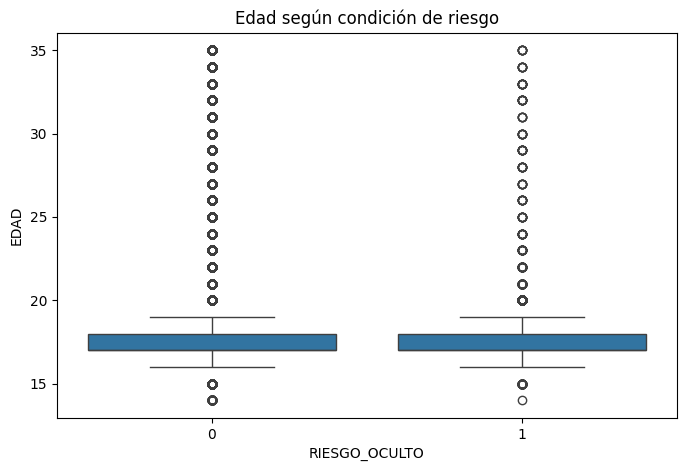

In [103]:
plt.figure(figsize=(8,5))

sns.boxplot(

x=
"RIESGO_OCULTO",

y=
"EDAD",

data=
df_vulnerabilidad

)

plt.title(
"Edad según condición de riesgo"
)

plt.show()